In [23]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38347,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41927,Total threads: 8
Dashboard: http://127.0.0.1:35277/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:45399,


### Load MITgcm Output from Assimilations

In [24]:
foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/energy_flux/'

In [25]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [26]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

2026-03-04 12:24:49,929 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f5a6ec59080>, <Task finished name='Task-9315' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.on_c

2026-03-04 12:24:50,231 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f374c656b60>, <Task finished name='Task-939481' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.on

In [27]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

In [44]:
lon = 190
lon_str = '170'

### Compute Density Anomaly

In [45]:
import numpy as np
import gsw  # TEOS-10, optional if using MITgcm EOS

# Constants
rho0 = 1035.0  # reference density
g = 9.81       # gravity

p = gsw.p_from_z(ds_tpose_TAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest'), p, ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_TAO.sel(XC=lon,YC=0.0,method='nearest').maskC)

# 2. pressure anomaly
rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
rho_dz = rho_anomaly * ds_tpose_TAO.drF * ds_tpose_TAO.sel(XC=lon,YC=0.0,method='nearest').hFacC  # shape (time, z)

# cumulative sum along vertical axis
p_prime = g*rho_dz.cumsum(dim='Z')

# add surface contribution everywhere 
# p_prime += rho0 * g * ds_tpose_TAO.ETAN.sel(XC=lon,YC=0.0,method='nearest') 

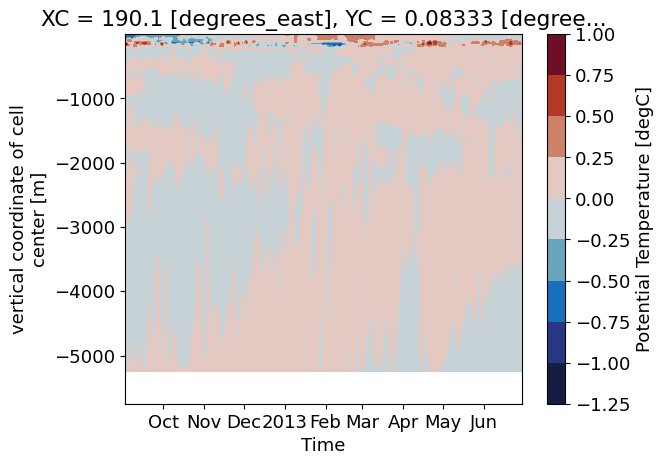

In [46]:
# rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)
rho_anomaly.plot.contourf(y='Z',cmap=cmo.balance)
# rho_anomaly.mean(dim='time').plot(y='Z')

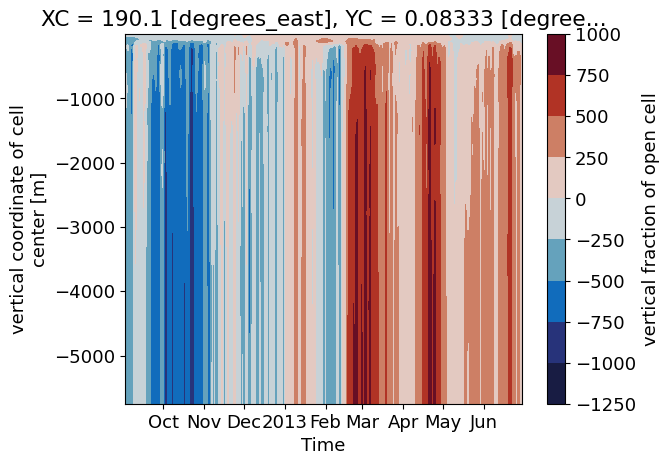

In [47]:
p_prime.plot.contourf(y='Z',cmap=cmo.balance)

In [48]:
from scipy.signal import butter, sosfiltfilt, detrend
# bandpass density (before reconstructing pressure)

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/10)*fs #  
lowF = (1/30)*fs #  
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

uvel = detrend(ds_tpose_TAO.UVEL.sel(XG=lon,YC=0.0,method='nearest'),axis=0)
uvel_anom = uvel - uvel.mean(axis=0)
vvel = detrend(ds_tpose_TAO.VVEL.sel(XC=lon,YG=0.0,method='nearest'),axis=0)
vvel_anom = vvel - vvel.mean(axis=0)
wvel = detrend(ds_tpose_TAO.WVEL.sel(XC=lon,YC=0.0,method='nearest'),axis=0)
wvel_anom = wvel - wvel.mean(axis=0)

p_prime_bandpass = sosfiltfilt(sos, detrend(p_prime,axis=0), axis=0)
uvel_prime = sosfiltfilt(sos, uvel_anom, axis=0)
vvel_prime = sosfiltfilt(sos, vvel_anom, axis=0)
wvel_prime = sosfiltfilt(sos, wvel_anom, axis=0)

In [49]:
temp = rho.copy(deep=True)
temp.data = p_prime_bandpass
p_prime_bandpass = temp

temp = ds_tpose_TAO.UVEL.sel(XG=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = uvel_prime
uvel_prime = temp

temp = ds_tpose_TAO.VVEL.sel(XC=lon,YG=0.0,method='nearest').copy(deep=True)
temp.data = vvel_prime
vvel_prime = temp

temp = ds_tpose_TAO.WVEL.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = wvel_prime
wvel_prime = temp

p_prime = p_prime_bandpass.where(ds_tpose_TAO.maskC.sel(XC=lon,YC=0.0,method='nearest'))

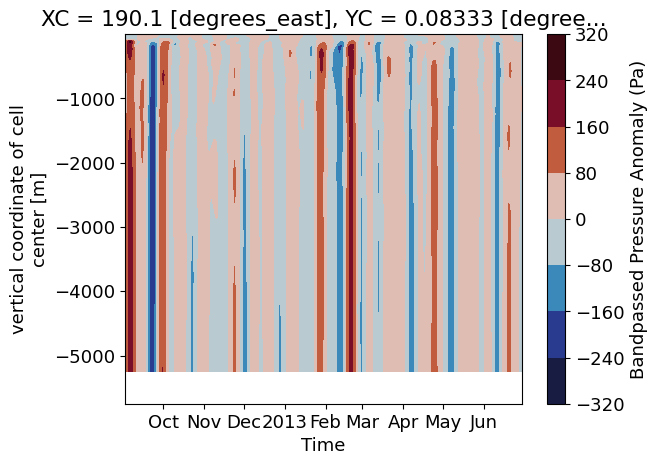

In [50]:
p_prime.plot.contourf(y='Z',cmap=cmo.balance,cbar_kwargs={'label':'Bandpassed Pressure Anomaly (Pa)'})

In [51]:
import xgcm
grid = xgcm.Grid(ds_tpose_TAO, periodic=['X','Y'])
w_prime_interp = grid.interp(wvel_prime, 'Z', boundary='fill')
Fx = (p_prime * uvel_prime).mean(dim="time")
Fy = (p_prime * vvel_prime).mean(dim="time")
Fz = (p_prime * w_prime_interp).mean(dim="time")

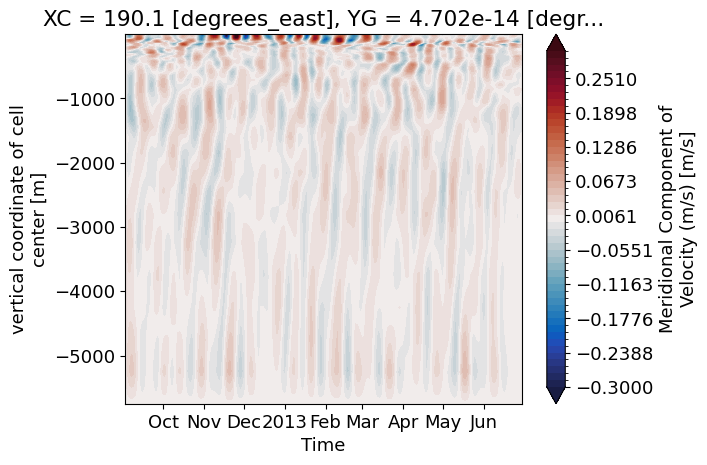

In [52]:
levels = np.linspace(-0.3,0.3,50)
vvel_prime.plot.contourf(y='Z',cmap=cmo.balance,levels=levels)

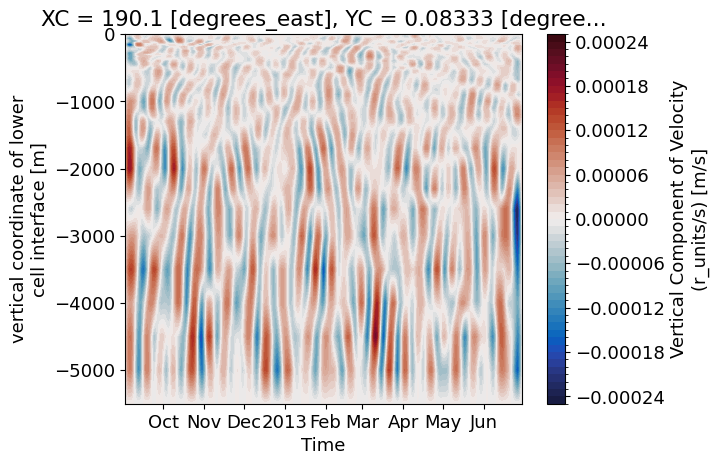

In [53]:
wvel_prime.plot.contourf(y='Zl',cmap=cmo.balance,levels=50)

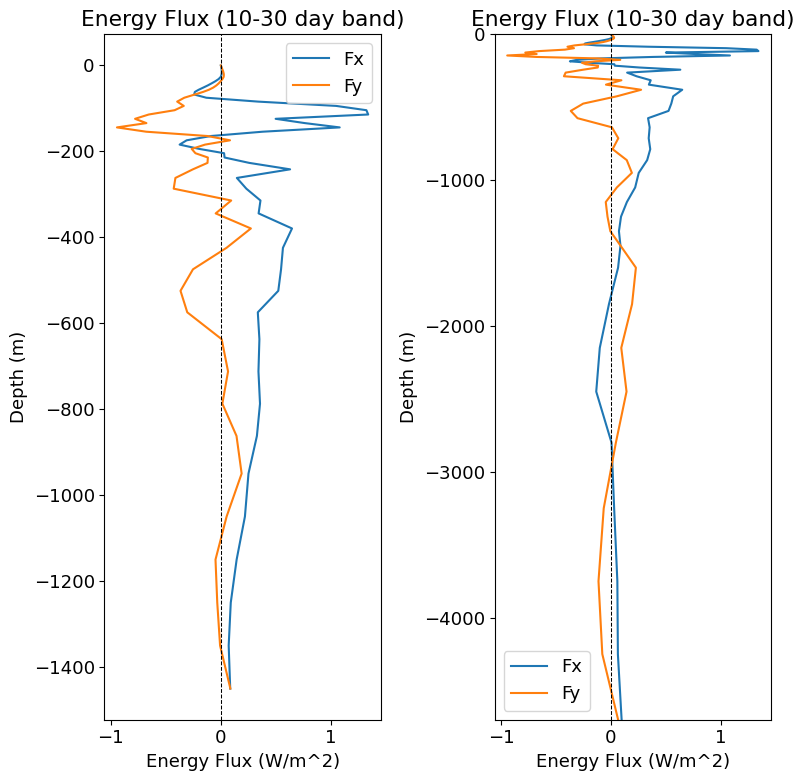

In [54]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fx.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fx')
Fy.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fy')
ax[0].legend()
ax[0].set_title('Energy Flux (10-30 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fx.plot(ax=ax[1],y='Z',label='Fx')
Fy.plot(ax=ax[1],y='Z',label='Fy')
ax[1].legend()
ax[1].set_title('Energy Flux (10-30 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'energy_flux_profiles_highfreq_' + lon_str + '.png',dpi=300)

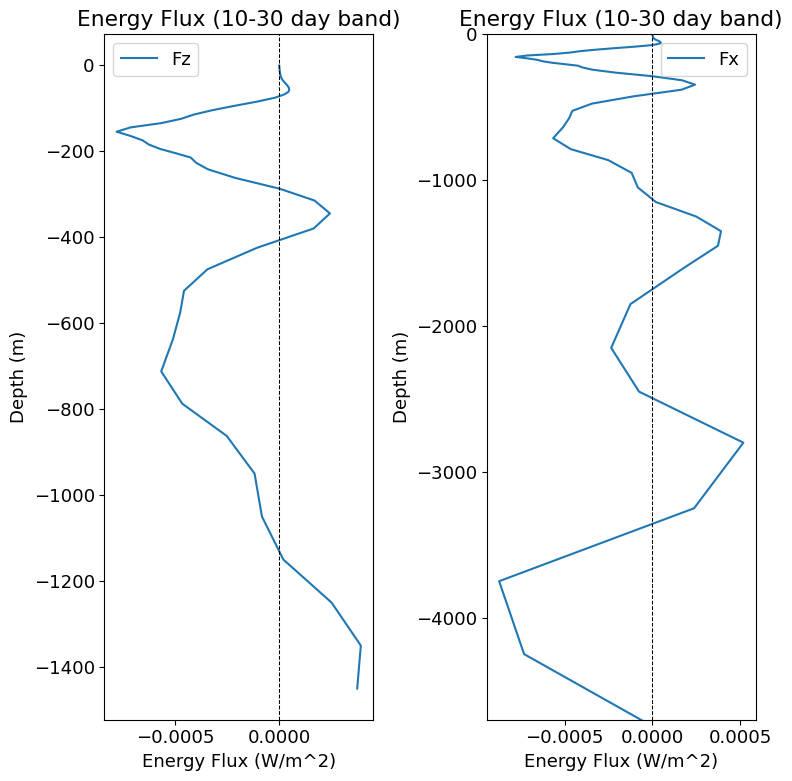

In [55]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fz.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz')
ax[0].legend()
ax[0].set_title('Energy Flux (10-30 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fz.plot(ax=ax[1],y='Z',label='Fx')
ax[1].legend()
ax[1].set_title('Energy Flux (10-30 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'Fz_profiles_highfreq_' + lon_str + '.png',dpi=300)

### Repeat without TAO assimilation

In [56]:
p = gsw.p_from_z(ds_tpose_noTAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_noTAO.SALT.sel(XC=lon,YC=0.0,method='nearest'), p, ds_tpose_noTAO.SALT.sel(XC=lon,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_noTAO.THETA.sel(XC=lon,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_noTAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_noTAO.sel(XC=lon,YC=0.0,method='nearest').maskC)

# 2. pressure anomaly
rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
rho_dz = rho_anomaly * ds_tpose_TAO.drF * ds_tpose_TAO.sel(XC=lon,YC=0.0,method='nearest').hFacC  # shape (time, z)

# cumulative sum along vertical axis
p_prime = g*rho_dz.cumsum(dim='Z')

uvel = detrend(ds_tpose_noTAO.UVEL.sel(XG=lon,YC=0.0,method='nearest'),axis=0)
uvel_anom = uvel - uvel.mean(axis=0)
vvel = detrend(ds_tpose_noTAO.VVEL.sel(XC=lon,YG=0.0,method='nearest'),axis=0)
vvel_anom = vvel - vvel.mean(axis=0)
wvel = detrend(ds_tpose_noTAO.WVEL.sel(XC=lon,YC=0.0,method='nearest'),axis=0)
wvel_anom = wvel - wvel.mean(axis=0)

p_prime_bandpass = sosfiltfilt(sos, detrend(p_prime,axis=0), axis=0)
uvel_prime = sosfiltfilt(sos, uvel_anom, axis=0)
vvel_prime = sosfiltfilt(sos, vvel_anom, axis=0)
wvel_prime = sosfiltfilt(sos, wvel_anom, axis=0)

temp = rho.copy(deep=True)
temp.data = p_prime_bandpass
p_prime_bandpass = temp

temp = ds_tpose_noTAO.UVEL.sel(XG=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = uvel_prime
uvel_prime = temp

temp = ds_tpose_noTAO.VVEL.sel(XC=lon,YG=0.0,method='nearest').copy(deep=True)
temp.data = vvel_prime
vvel_prime = temp

temp = ds_tpose_noTAO.WVEL.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = wvel_prime
wvel_prime = temp

p_prime = p_prime_bandpass.where(ds_tpose_noTAO.maskC.sel(XC=lon,YC=0.0,method='nearest'))

In [57]:
grid = xgcm.Grid(ds_tpose_noTAO, periodic=['X','Y'])
w_prime_interp = grid.interp(wvel_prime, 'Z', boundary='fill')
Fx_noTAO = (p_prime * uvel_prime).mean(dim="time")
Fy_noTAO = (p_prime * vvel_prime).mean(dim="time")
Fz_noTAO = (p_prime * w_prime_interp).mean(dim="time")

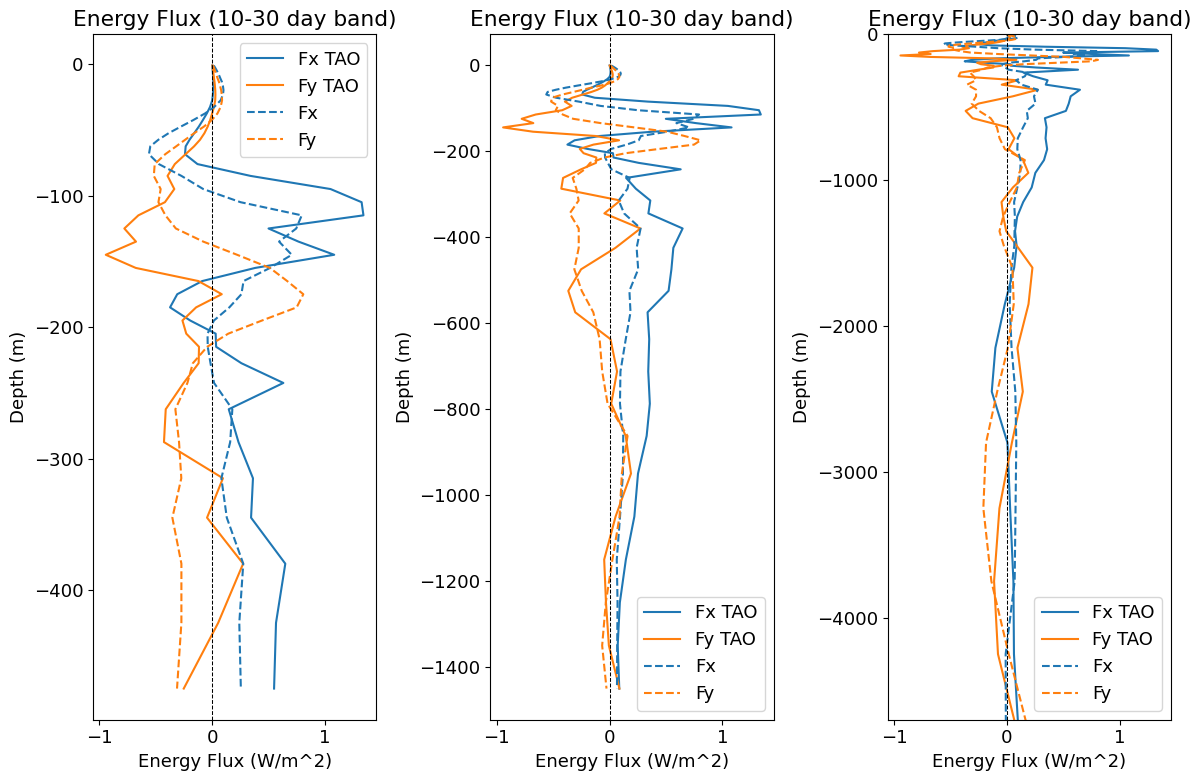

In [58]:
fig, ax = plt.subplots(figsize=(12,8),ncols=3)

Fx.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fx TAO',color='tab:blue')
Fy.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fy',ls='--',color='tab:orange')
ax[0].legend()
ax[0].set_title('Energy Flux (10-30 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fx.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fx TAO',color='tab:blue')
Fy.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fy',ls='--',color='tab:orange')
ax[1].legend()
ax[1].set_title('Energy Flux (10-30 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
ax[1].axvline(0,color='k',ls='--',lw=0.75)

Fx.plot(ax=ax[2],y='Z',label='Fx TAO',color='tab:blue')
Fy.plot(ax=ax[2],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.plot(ax=ax[2],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.plot(ax=ax[2],y='Z',label='Fy',ls='--',color='tab:orange')
ax[2].legend()
ax[2].set_title('Energy Flux (10-30 day band)')
ax[2].set_xlabel('Energy Flux (W/m^2)')
ax[2].set_ylabel('Depth (m)')
ax[2].axvline(0,color='k',ls='--',lw=0.75)
ax[2].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'energy_flux_profiles_compare_highfreq_' + lon_str + '.png',dpi=300)

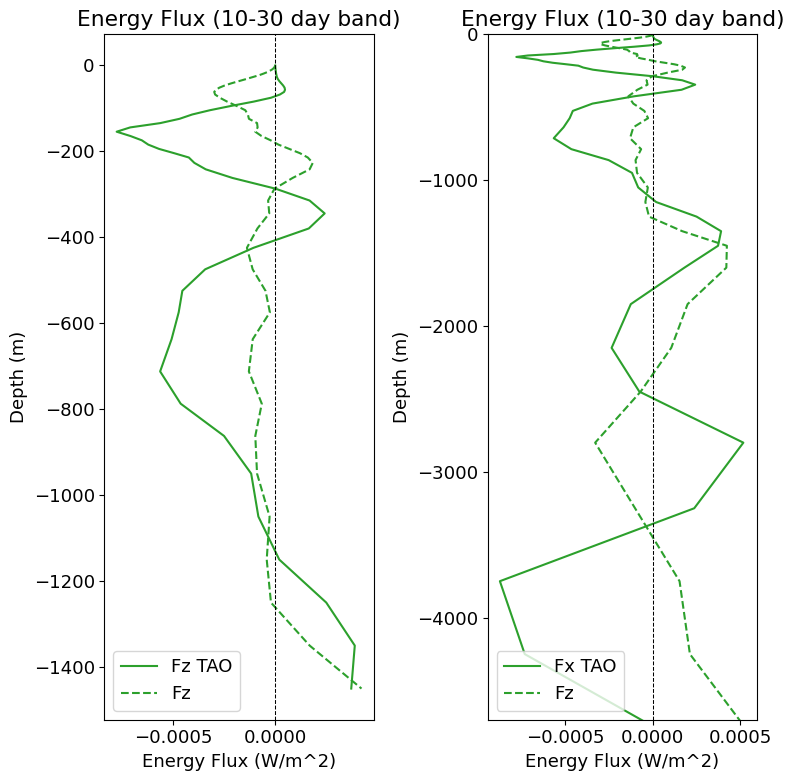

In [59]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fz.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz TAO',color='tab:green')
Fz_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz',ls='--',color='tab:green')
ax[0].legend()
ax[0].set_title('Energy Flux (10-30 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fz.plot(ax=ax[1],y='Z',label='Fx TAO',color='tab:green')
Fz_noTAO.plot(ax=ax[1],y='Z',label='Fz',ls='--',color='tab:green')
ax[1].legend()
ax[1].set_title('Energy Flux (10-30 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'Fz_profiles_compare_highfreq_' + lon_str + '.png',dpi=300)

In [60]:
client.shutdown()
cluster.close()
client.close()